# DG advection with a vortex in a rectangle

$$
\mathbb{S}
\begin{cases}
\Omega = [0, 1] \times [0, 1] \\
u_0(x,y) = U_0x^2(1-x)^4y^2(1-y)^4 \\
\textbf{a} = \begin{pmatrix}
\sin(\pi x)\cos(\pi y) \\
-\cos(\pi x)\sin(\pi y)
\end{pmatrix}
\end{cases}
$$

In [6]:
import numpy as np
from ufl import SpatialCoordinate, as_vector, sin, cos
from lucifex.mesh import rectangle_mesh
from lucifex.fem import Constant
from lucifex.fdm import (BE, FE, 
    FiniteDifference, FunctionSeries, ConstantSeries,
    advective_timestep)
from lucifex.solver import ibvp , BoundaryConditions
from lucifex.sim import run, Simulation
from lucifex.viz import plot_colormap, save_figure, plot_streamlines        
from lucifex.utils.py_utils import nested_dict, is_continuous_lagrange, as_index
from lucifex.pde.advection import advection, dg_advection


def create_simulation(
    element: tuple[str, int],
    Lx: float,
    Ly: float,
    Nx: int,  
    Ny: float,  
    courant: float,
    D_adv: FiniteDifference,
    mu: float,
):
    mesh = rectangle_mesh(Lx, Ly, Nx, Ny)
    t = ConstantSeries(mesh, name='t', ics=0.0)
    x = SpatialCoordinate(mesh)
    a = as_vector(
        (sin(np.pi * x[0]) * cos(np.pi * x[1]), -cos(np.pi * x[0]) * sin(np.pi * x[1]))
    )
    dt = advective_timestep(a, 'hmin', courant, mesh=mesh)
    dt = Constant(mesh, dt, name='dt')
    u = FunctionSeries((mesh, *element), name='u', store=1)
    ics = lambda x: mu * (x[0] ** 2) * (x[1] ** 2) * ((1 - x[0]) ** 4) * ((1 - x[1]) ** 4)
    bcs = BoundaryConditions(
        ('dirichlet', lambda x: x[0], 0.0),
    )
    if is_continuous_lagrange(u.function_space):
        u_solver = ibvp(advection, ics, bcs)(u, dt, a, D_adv)
    else:
        u_solver = ibvp(dg_advection, ics)(u, dt, a, D_adv, bcs=bcs)
    return Simulation(u_solver, t, dt, auxiliary=[('a', a)])


Lx = 1.0
Ly = 1.0
Nx = 64
Ny = 64
h = Lx / Nx
mu = 1e3
courant = 0.8

elem_opts = [
    ('DP', 1),
    ('P', 1),
]
D_adv_opts = (BE, FE)

simulations = nested_dict((FiniteDifference, tuple, Simulation))

for elem in elem_opts:
    for D_adv in D_adv_opts:
        simulations[elem][D_adv] = create_simulation(elem, Lx, Ly, Nx, Ny, courant, D_adv, mu)

n_stop = 100
for elem in elem_opts:
    for D_adv in D_adv_opts:
        run(simulations[elem][D_adv], n_stop)

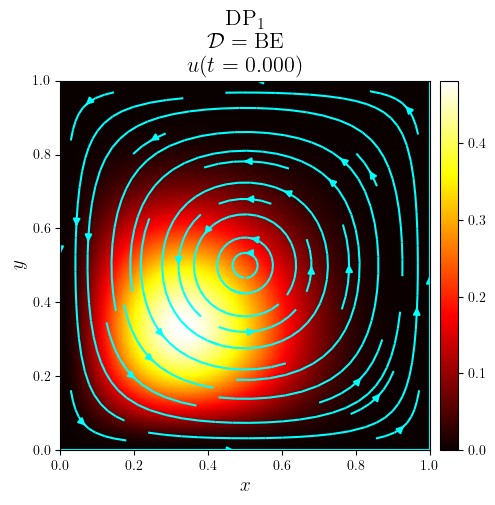

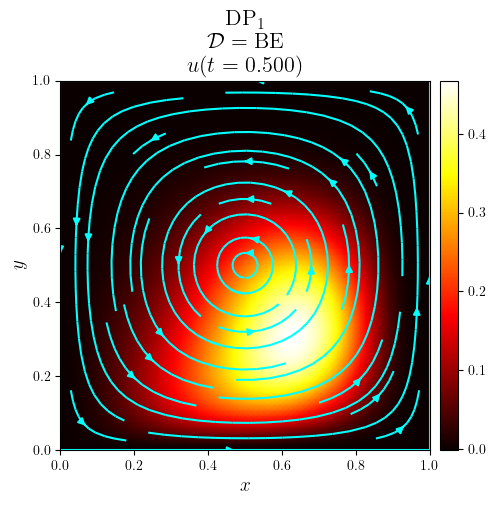

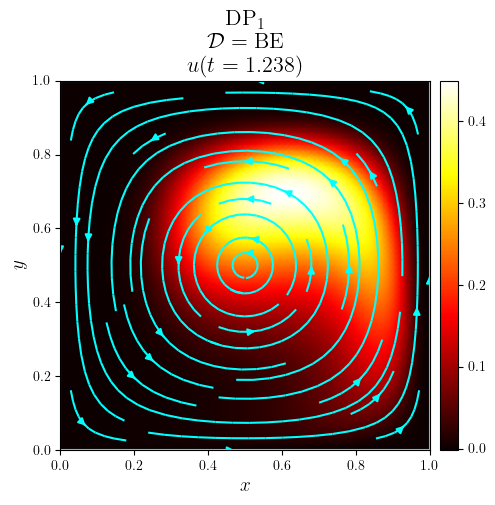

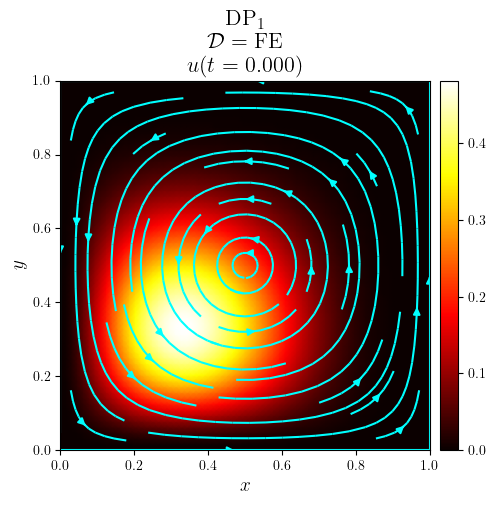

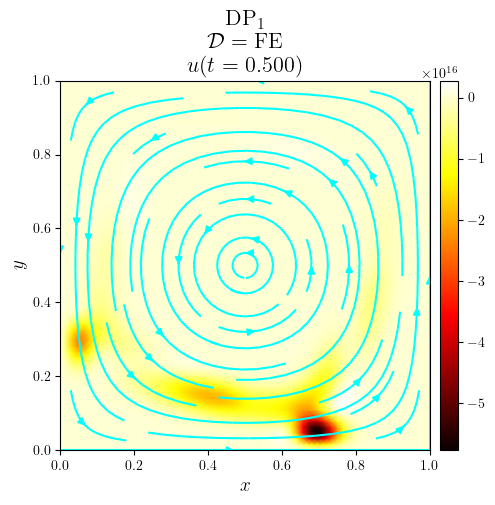

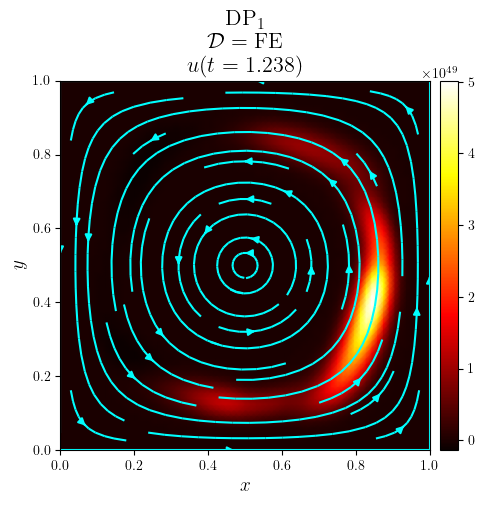

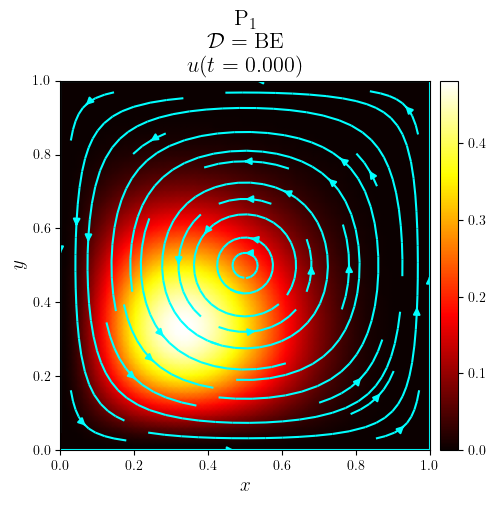

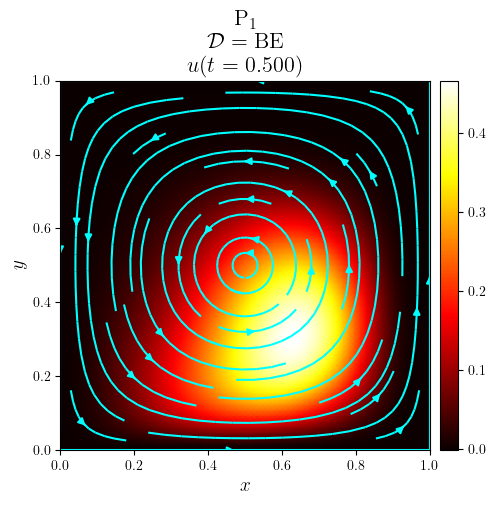

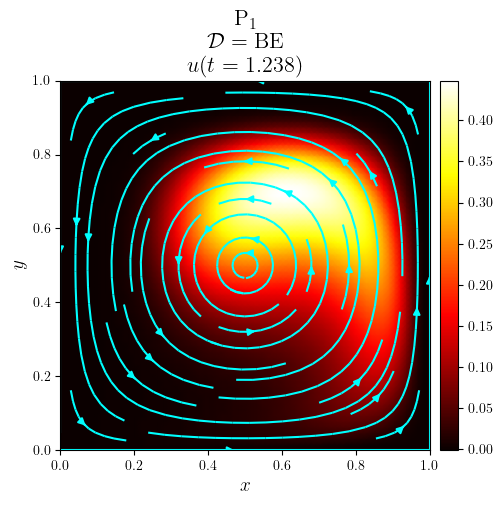

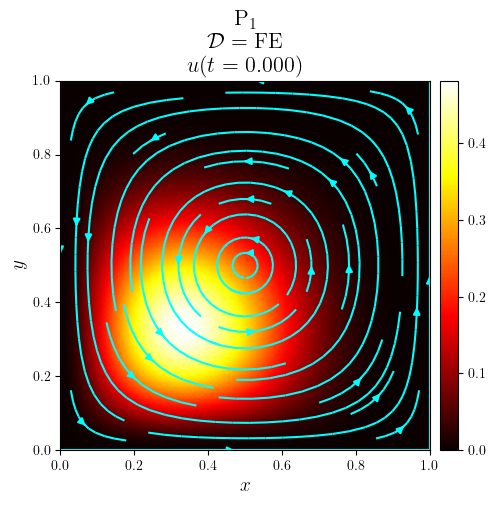

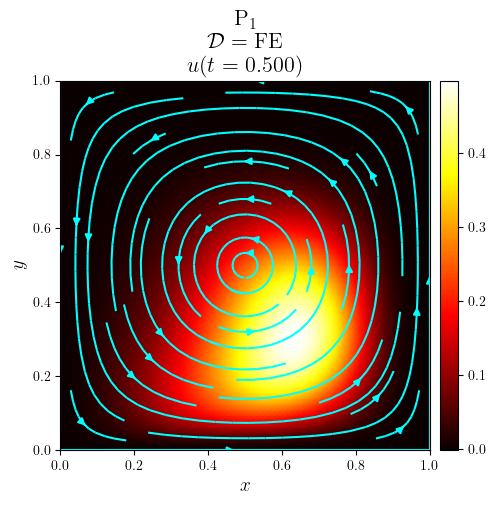

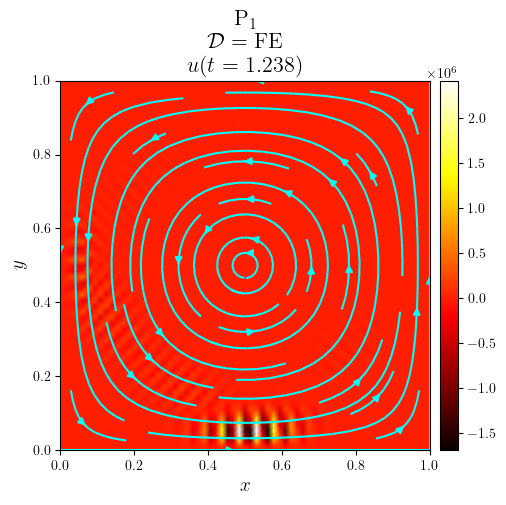

In [7]:
for elem in elem_opts:
    fam, deg = elem
    for D_adv in D_adv_opts:
        u = simulations[elem][D_adv]['u']
        a = simulations[elem][D_adv]['a']
        time_indices = as_index(u.time_series, (0, 0.5, -1),)
        for i in time_indices:
            t = u.time_series[i]
            title = f'{fam}$_{deg}$\n $\mathcal{{D}}=\mathrm{{{D_adv}}}$\n $u(t={t:.3f})$'
            fig, ax = plot_colormap(u.series[i], title=title)
            plot_streamlines(fig, ax, a, mesh=u.function_space.mesh, density=0.75, color='cyan')
            thumbnail = (elem == ('DP', 1) and i == -1 and D_adv is BE)
            save_figure(f'{u.name}(x,y,t={t:.3f})_{fam}{deg}_{D_adv}', thumbnail=thumbnail)(fig)